# Титаник — предсказание выживших
## Ноутбук 01 — Данные и разведочный анализ (EDA)

**Цель проекта / Goal.** Обучить `RandomForestClassifier`, предсказать `survived`, сообщить accuracy на тесте (split 80/20, `random_state=42`). Параллельно — довести до портфолио-уровня: честные фичи, без утечек, с понятной историей.

**Этот ноутбук / This notebook.** Смотрим на данные глазами: что есть, где пропуски, кто выживал чаще, где спрятан сигнал.

## План проекта / Project plan

**Шаг 1. Посмотреть данные** — этот ноутбук (01).

**Шаг 2. Убрать колонки-утечки.** `boat`, `body`, `home.dest` известны только после катастрофы → выбрасываем ради честности.

**Шаг 3. Создание признаков — под-блоки** (ноутбук 02):
- **А — Классика:** титул, пол, класс, возраст, цена, порт, размер семьи, «едет один», палуба, «есть каюта».
- **Б — Наши идеи:** цена на человека, флаги пропусков как сигнал, `пол×класс`, флаги «ребёнок»/«мать», приставка билета, число кают.
- **В — Доп. идеи на проверку** (ноутбук 03, честным OOF-способом): кластер, вероятность от другой модели, состав группы. Отдельно проверили «выживаемость по билету» — она помогает, но **отклонена как утечка через сплит**.
- **Г — Слабые/спорные:** длина имени.

> Правило Б/В/Г: добавили → проверили на точности → оставили только то, что реально помогло.

**Шаг 4. Заполнить пропуски** — медиана для чисел, частое значение для категорий (внутри `Pipeline`, только по train). Групповую импьютацию возраста (титул×класс) проверили — прирост ~0.004, оставили простую медиану ради чистоты.

**Шаг 5. Обучить лес, замерить accuracy** (split 80/20).

**Шаг 6. Тюнинг (Optuna), интерпретация (SHAP), сравнение моделей** (ноутбуки 02–03).

**Шаг 7. Финальный скрипт-решение** — отдельный чистый воспроизводимый скрипт, печатает `Accuracy on test: 0.XXXX`.

**Шаг 8. (Опционально) Бонус-глава** «что влияло на выживание» — объяснение, не предсказание.

**Цель честной точности: ~0.80 на тесте / ~0.82 на кросс-валидации** (без утечек).

### Почему без GPU / Why no GPU
Финальная модель `RandomForestClassifier` (sklearn) работает только на CPU. Датасет — 1309 строк, это меньше накладных расходов на видеопамять; даже XGBoost/LightGBM на GPU были бы медленнее. GPU оправдана на больших данных или нейросетях — здесь это был бы лишний «хайп». Считаем на CPU (секунды).

In [1]:
# Подключаем общий модуль проекта / import shared project module
import sys, pathlib
p = pathlib.Path.cwd()
ROOT = next((q for q in [p, *p.parents] if (q / 'src' / 'titanic_utils.py').exists()), p)
sys.path.insert(0, str(ROOT / 'src'))
import titanic_utils as tu

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 60)
print('project root:', ROOT)

project root: /home/mchunikhin/titanic_project


## 1. Загрузка данных / Load data
Грузим как в задании (`fetch_openml('titanic', version=1)`), но через кэш — чтобы не ходить в сеть и работать офлайн.

In [2]:
df = tu.load_data()          # первый запуск качает и кэширует в data/ / downloads & caches
y = tu.get_target(df)         # survived -> int 0/1
print('SHAPE:', df.shape)
df.head()

SHAPE: (1309, 14)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## 2. Структура: типы, пропуски, баланс / Structure: dtypes, missing, balance

In [3]:
miss = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
print('--- ТИПЫ / dtypes ---'); print(df.dtypes)
print('\n--- ПРОПУСКИ %, / missing % ---'); print(miss)
print('\n--- ТАРГЕТ / target survived ---'); print(y.value_counts())
print('Доля выживших / survival rate:', round(y.mean(), 4))
print('Baseline "всех в 0" / majority-class acc:', round((y == 0).mean(), 4))

--- ТИПЫ / dtypes ---
pclass          int64
survived     category
name              str
sex          category
age           float64
sibsp           int64
parch           int64
ticket            str
fare          float64
cabin             str
embarked     category
boat              str
body          float64
home.dest         str
dtype: object

--- ПРОПУСКИ %, / missing % ---
body         90.8
cabin        77.5
boat         62.9
home.dest    43.1
age          20.1
embarked      0.2
fare          0.1
sibsp         0.0
name          0.0
survived      0.0
pclass        0.0
sex           0.0
parch         0.0
ticket        0.0
dtype: float64

--- ТАРГЕТ / target survived ---
survived
0    809
1    500
Name: count, dtype: int64
Доля выживших / survival rate: 0.382
Baseline "всех в 0" / majority-class acc: 0.618


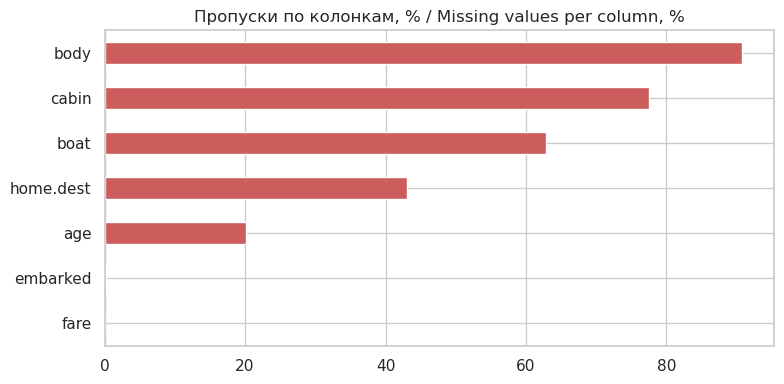

In [4]:
# График пропусков / missingness chart
ax = miss[miss > 0].plot.barh(figsize=(8, 4), color='indianred')
ax.set_title('Пропуски по колонкам, % / Missing values per column, %')
ax.invert_yaxis(); plt.tight_layout(); plt.show()

📝 **Вывод (структура).** 1309 строк × 14 колонок. Таргет умеренно несбалансирован (~38% выжили), глупый baseline «всех в 0» даёт ~0.62 — это нижняя планка, которую надо бить. Сильные пропуски: `body` 91%, `cabin` 77%, `boat` 63% — но `body`/`boat` мы и так выбросим как утечки.

## 3. Текстовые колонки — где сигнал, где шум / Text columns: signal vs noise
Нужен ли BERT? Нет: текст служебный, сигнал — в одном токене (титул) и в группировке (билет/фамилия).

In [5]:
df[['name', 'ticket', 'cabin', 'home.dest']].head(8)

,name,ticket,cabin,home.dest
0,"Allen, Miss. Elisabeth Walton",24160,B5,"St Louis, MO"
1,"Allison, Master. Hudson Trevor",113781,C22 C26,"Montreal, PQ / Chesterville, ON"
2,"Allison, Miss. Helen Loraine",113781,C22 C26,"Montreal, PQ / Chesterville, ON"
3,"Allison, Mr. Hudson Joshua Creighton",113781,C22 C26,"Montreal, PQ / Chesterville, ON"
4,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",113781,C22 C26,"Montreal, PQ / Chesterville, ON"
5,"Anderson, Mr. Harry",19952,E12,"New York, NY"
6,"Andrews, Miss. Kornelia Theodosia",13502,D7,"Hudson, NY"
7,"Andrews, Mr. Thomas Jr",112050,A36,"Belfast, NI"


## 4. Титул из имени / Title from name — сильнейший признак

In [6]:
raw_title = df['name'].str.extract(r',\s*([^.]+)\.')[0].str.strip()
tab = pd.DataFrame({'title': raw_title, 'survived': y})
g = tab.groupby('title')['survived'].agg(['mean', 'count'])
print('Survival rate по титулу (где >=5 чел) / by title (n>=5):')
print(g[g['count'] >= 5].sort_values('mean', ascending=False).round(3))

Survival rate по титулу (где >=5 чел) / by title (n>=5):
         mean  count
title               
Mrs     0.787    197
Miss    0.677    260
Master  0.508     61
Dr      0.500      8
Mr      0.162    757
Rev     0.000      8


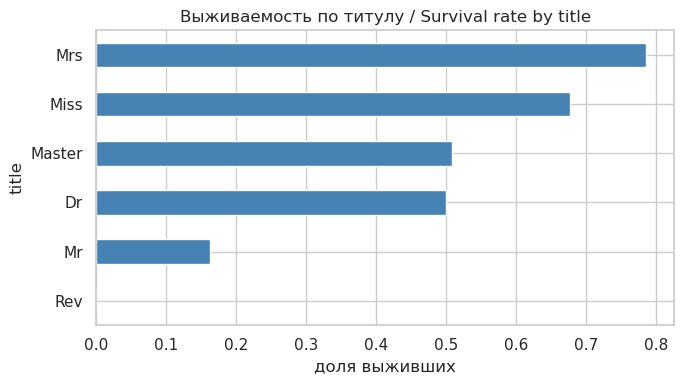

In [7]:
order = g[g['count'] >= 5].sort_values('mean').index
ax = g.loc[order, 'mean'].plot.barh(figsize=(7, 4), color='steelblue')
ax.set_title('Выживаемость по титулу / Survival rate by title')
ax.set_xlabel('доля выживших'); plt.tight_layout(); plt.show()

📝 **Вывод (титул).** Mrs/Miss/Master выживали в разы чаще, чем Mr. Титул кодирует пол+возраст+статус одной фичей — берём в классику (под-блок А).

## 5. Семьи и группы по билету / Families & ticket groups

In [8]:
surname = df['name'].str.split(',').str[0].str.strip()
tgs = df.groupby('ticket')['ticket'].transform('count')
family = df['sibsp'] + df['parch'] + 1
print('Размер группы по билету / ticket group size:')
print(tgs.value_counts().sort_index().to_dict())
print('FamilySize:', family.value_counts().sort_index().to_dict())
print('Уникальных фамилий / unique surnames:', surname.nunique(), 'из', len(df))

# Цена на человека: fare — за весь билет / fare is per-ticket
fpp = df['fare'] / tgs
print('\nfare (медиана):', round(df["fare"].median(), 2),
      '| fare на человека (медиана):', round(fpp.median(), 2))

Размер группы по билету / ticket group size:
{1: 713, 2: 264, 3: 147, 4: 64, 5: 35, 6: 24, 7: 35, 8: 16, 11: 11}
FamilySize: {1: 790, 2: 235, 3: 159, 4: 43, 5: 22, 6: 25, 7: 16, 8: 8, 11: 11}
Уникальных фамилий / unique surnames: 875 из 1309

fare (медиана): 14.45 | fare на человека (медиана): 8.05


📝 **Вывод (группы).** По одному билету часто едут 2–7 человек → `fare` это цена за всех, делим на размер группы (идея «цена на человека», под-блок Б). Групповую структуру (семьи) дальше используем честно — через размер группы; а основанную на исходах «выживаемость по билету» в ноутбуке 03 проверим и отклоним как утечку.

## 6. ⚠️ Утечки: boat и body / Leakage demo
`boat` (шлюпка) и `body` (номер тела) известны только ПОСЛЕ катастрофы — это прямые маркеры исхода.

In [9]:
has_boat = df['boat'].notna(); has_body = df['body'].notna()
print('survival | есть boat:', round(y[has_boat].mean(), 3), f'(n={has_boat.sum()})')
print('survival | нет boat: ', round(y[~has_boat].mean(), 3), f'(n={(~has_boat).sum()})')
print('survival | есть body:', round(y[has_body].mean(), 3), f'(n={has_body.sum()})')
print('=> boat/body почти идеально предсказывают исход. Это утечка. Выбрасываем:', tu.LEAKS)

survival | есть boat: 0.981 (n=486)
survival | нет boat:  0.028 (n=823)
survival | есть body: 0.0 (n=121)
=> boat/body почти идеально предсказывают исход. Это утечка. Выбрасываем: ['boat', 'body', 'home.dest']


In [10]:
# Наглядно: с утечкой точность фейково огромная / how fake-high leakage looks
leak_acc = max(y[has_boat].mean(), 1 - y[has_boat].mean()) * has_boat.mean() + \
           max(y[~has_boat].mean(), 1 - y[~has_boat].mean()) * (~has_boat).mean()
print(f'Тривиальное правило по boat дало бы ~{leak_acc:.3f} accuracy — но это фикция.')
print('Поэтому наша ЧЕСТНАЯ цель ниже (~0.80-0.83), зато защищаемая.')

Тривиальное правило по boat дало бы ~0.976 accuracy — но это фикция.
Поэтому наша ЧЕСТНАЯ цель ниже (~0.80-0.83), зато защищаемая.


## 7. Базовые графики / Core graphs

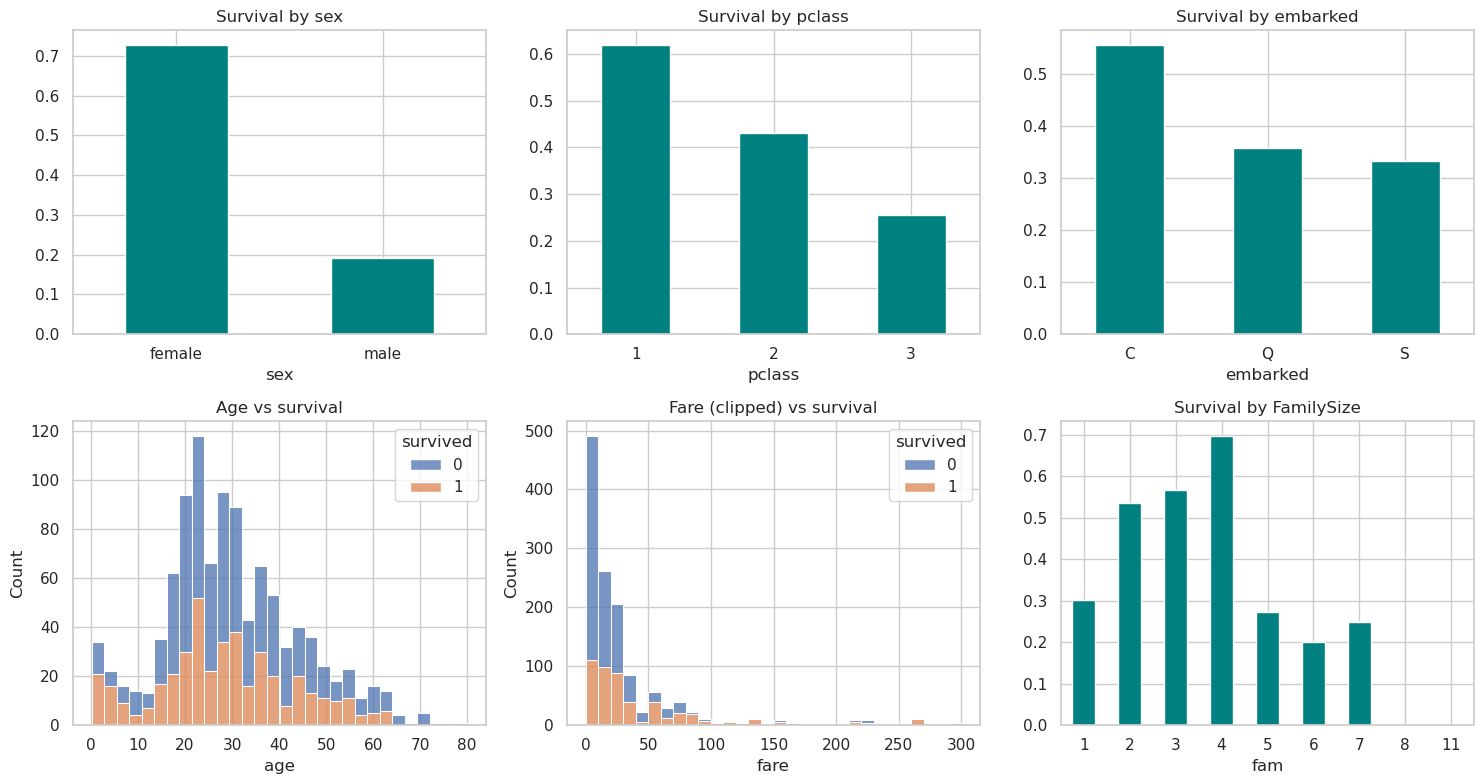

In [11]:
d = df.assign(survived=y)
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
d.groupby('sex')['survived'].mean().plot.bar(ax=ax[0, 0], title='Survival by sex', color='teal')
d.groupby('pclass')['survived'].mean().plot.bar(ax=ax[0, 1], title='Survival by pclass', color='teal')
d.groupby('embarked')['survived'].mean().plot.bar(ax=ax[0, 2], title='Survival by embarked', color='teal')
sns.histplot(data=d, x='age', hue='survived', bins=30, ax=ax[1, 0], multiple='stack')
ax[1, 0].set_title('Age vs survival')
sns.histplot(data=d.assign(fare=d['fare'].clip(upper=300)), x='fare', hue='survived', bins=30, ax=ax[1, 1], multiple='stack')
ax[1, 1].set_title('Fare (clipped) vs survival')
d.assign(fam=family).groupby('fam')['survived'].mean().plot.bar(ax=ax[1, 2], title='Survival by FamilySize', color='teal')
for a in ax.ravel():
    a.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## Итоги EDA / EDA conclusions

📝 **Что увидели / takeaways:**
- Сильнейшие сырые сигналы: **пол** (женщины выживали кратно чаще) и **класс** (1-й класс >> 3-й).
- **Возраст:** у детей шанс выше. **Цена:** дороже билет → выше класс → выше шанс.
- **Семья:** одиночки и очень большие семьи выживали хуже, чем семьи 2–4 человека.
- **Текст не требует BERT:** весь сигнал имени — в титуле.
- **Утечки `boat`/`body`** дают фейковые ~0.97; выбрасываем ради честности.

➡️ Дальше: **ноутбук 02** — создаём признаки (А+Б), проверяем их статистически (Mutual Information, Cramér's V), сравниваем модели.